# **Exploring Missing Data Imputation Methods for VM Data**
### 📌 Notebook Aim
This notebook investigates the **quality** of different methods for imputing missing values in VM (Virtual Machine) data. We explore both simple statistical approaches and advanced machine learning-based techniques to handle **single-record** missing values as well as **missing gaps** within the data. The goal is to determine the method that **minimizes distortion** while preserving the original data distribution.

### 🛠 **Imputation Methods Explored**
1. **Statistical Methods (Pandas)**
   - 📊 **Median Imputation**: `df['column'].median()`
   - 📈 **Linear Interpolation**: `df['column'].interpolate(method='linear')`
   - 🔍 **Nearest Neighbor Interpolation**: `df['column'].interpolate(method='nearest')`
   - 🎢 **Spline Interpolation**: `df['column'].interpolate(method='spline', order=1)`
   - 📐 **Polynomial Interpolation**: `df['column'].interpolate(method='polynomial', order=1)`

2. **Deep Learning-Based Approach**
   - 🤖 **SAITS (Self-Attention-based Imputation for Time Series, 2023)**
     - [GitHub Repository](https://github.com/WenjieDu/SAITS)
     - [Research Paper](https://www.sciencedirect.com/science/article/pii/S0957417423001203?via%3Dihub)


# Hyperparameters for Missing Value Imputation Methods

| Method                          | Hyperparameters                  | Default Values  | Description |
|---------------------------------|--------------------------------|----------------|-------------|
| **fill_nan_with_median**        | None | - | Uses column-wise median to fill NaNs |
| **fill_nan_with_linear**        | None | - | Uses linear interpolation |
| **fill_nan_with_nearest**       | None | - | Uses nearest neighbor interpolation |
| **fill_nan_with_spline**        | `order` | `1` | Uses spline interpolation (order=1 ≈ linear) |
| **fill_nan_with_polynomial**    | `order` | `1` | Uses polynomial interpolation (order=1 ≈ linear) |
| **FillNaNWithDeepLearning**     | `columns` | `[]` | List of columns to impute |
|                                 | `n_steps` | `100` | Number of time steps |
|                                 | `n_features` | `1` | Feature dimension |
|                                 | `n_layers` | `2` | Number of Transformer layers |
|                                 | `d_model` | `256` | Embedding size |
|                                 | `n_heads` | `4` | Attention heads |
|                                 | `d_k, d_v` | `64` | Key/Value dimensions |
|                                 | `d_ffn` | `128` | Feedforward layer size |
|                                 | `dropout` | `0.1` | Dropout probability |
|                                 | `epochs` | `50` | Training epochs |

### ⚠️ **notes**:
For Interpolation Methods:
- `spline` and `polynomial` use `order=1`, which is just linear. Consider `order=2` or 3 for better smoothing.
- For `FillNaNWithDeepLearning`: Consider making `n_steps` dynamic `(min(100, len(X)))` to avoid reshaping issues.


### 📊 **Evaluation Strategy**
- Apply each imputation method to missing values in VM data.
- Compare the effectiveness of each approach based on statistical and visual analysis.
- Identify the method that introduces the least deviation from the original dataset.

### 🚀 **Usage Instructions**
1. Ensure the dataset containing missing values is loaded.
2. Execute each imputation technique and analyze the results.
3. Compare the performance of different approaches and choose the best-suited method.

### ⚠️ **Prerequisites**
- Install required libraries: `pandas`, `numpy`, `matplotlib`, and `SAITS` dependencies if not already available.
- Ensure the dataset is preprocessed correctly before running imputation.
- Ensure to upload VM sample time data:  `vmid__KlNtIK2BCkiGhURgesiA_MQNyTpAgt7daSRsu2kJldWyCBGwnZCbtXR3w+vR4kq.csv`.

---

✅ **Author**: _[Mehryar Majd]_  
📅 **Last Updated**: _March 2025_

📌 Necessary considerations should be made regarding the new version of pypots.

### 0. Recover original `vmid` from stored `csv` filenames if you check from `vmtable.csv` in `V1` or `V2` datasets

In [97]:
import re

# Dictionary to store original vmid
vmid_map = {}

def sanitize_filename(vmid):
    sanitized = re.sub(r'[<>:"/\\|?*]', '_', vmid)
    vmid_map[sanitized] = vmid  # Store original vmid
    return sanitized

def unsanitize_filename(sanitized):
    return vmid_map.get(sanitized, None)  # Retrieve original vmid

# Example usage
vmid = "/KlNtIK2BCkiGhURgesiA_MQNyTpAgt7daSRsu2kJldWyCBGwnZCbtXR3w+vR4kq"
sanitized = sanitize_filename(vmid)
print("Sanitized VMID to store csv filename:", sanitized)

# Reverse lookup
original_vmid = unsanitize_filename(sanitized)
print("Recovered original VMID:", original_vmid)


Sanitized VMID to store csv filename: _KlNtIK2BCkiGhURgesiA_MQNyTpAgt7daSRsu2kJldWyCBGwnZCbtXR3w+vR4kq
Recovered original VMID: /KlNtIK2BCkiGhURgesiA_MQNyTpAgt7daSRsu2kJldWyCBGwnZCbtXR3w+vR4kq


### 1. Dependencies

In [23]:
# !pip install session_info
# !pip install pypots==0.8.1

In [24]:
# Time
# ==============================================================================
import time
import datetime as dt
from datetime import datetime,timedelta


dtime = dt.time()
now = dt.datetime.now()
zeit = now.strftime("%Y-%m-%d %H:%M:%S")
print(f"Last update of notebook: {zeit}" )
#print("Last update of notebook:": format.zeit)

Last update of notebook: 2025-03-17 18:57:41


In [25]:
# # Mount Google Drive
# # ==============================================================================
# from google.colab import drive
# drive.mount("/content/drive", force_remount=True)

In [26]:
import glob
from typing import List

# Data manipulation
# ==============================================================================
import numpy as np
import pandas as pd

# Plots
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

# Pre-processing, Modeling and Forecasting and display pipeline , metrics
# ==============================================================================
#from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.signal import savgol_filter
from pypots.imputation import SAITS


# Warnings configuration
# ==============================================================================
import warnings
# warnings.filterwarnings('ignore')

In [27]:
# Session information
import session_info
session_info.show(html=False)

-----
matplotlib          3.10.0
numpy               2.0.2
pandas              2.2.2
pypots              0.8.1
scipy               1.14.1
seaborn             0.13.2
session_info        1.0.0
sklearn             1.6.1
-----
IPython             7.34.0
jupyter_client      6.1.12
jupyter_core        5.7.2
notebook            6.5.5
-----
Python 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
Linux-6.1.85+-x86_64-with-glibc2.35
-----
Session information updated at 2025-03-17 18:57


###  <font  color='darkred'> **RUN FROM HERE =====>** </font>

### 3. Main

#### Logging | Notebook Start Time

In [28]:
NOTEBOOK_START_TIME_UC0 = time.time() #now.strftime("%Y-%m-%d %H:%M:%S") #time.time_ns()  #time.time()
print(f"================[INFO]{zeit}===================")
print(f"| Starting the execution of Notebook at: {NOTEBOOK_START_TIME_UC0} | \n ----------------------------------------------------------- ")

================[INFO]2025-03-17 18:57:41===================
| Starting the execution of Notebook at: 1742237861.8902335 | 
 ----------------------------------------------------------- 


#### Pre-processing

- Read & load data from `csv` in **Google Drive**
- select intereted column for TSA `avg CPU`
- Data cleaning
  - Time resolution control
- Split the time-series data

# **Read/load data**

In [29]:
data  = pd.read_csv('/content/vmid__KlNtIK2BCkiGhURgesiA_MQNyTpAgt7daSRsu2kJldWyCBGwnZCbtXR3w+vR4kq.csv')

start_date = pd.to_datetime('2019-01-01')
data['timestamp'] = start_date + pd.to_timedelta(data['timestamp'], unit='s')


In [30]:
data.head()

,timestamp,vmid,mincpu,maxcpu,avgcpu
0,2019-01-26 04:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.194572,48.802255,10.946638
1,2019-01-26 04:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.453188,22.040510,7.059620
2,2019-01-26 04:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.399952,6.248477,5.021625
3,2019-01-26 04:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.288921,28.744898,9.819682
4,2019-01-26 04:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.695492,39.624177,11.086075


### 2. Configuration

# **slice data** + set winodw width (lag)

In [31]:
# Configuration
# ==============================================================================
steps = 864 #3*288
lags = 288
name_columns = "avgcpu"

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8631 entries, 0 to 8630
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8631 non-null   datetime64[ns]
 1   vmid       8631 non-null   object        
 2   mincpu     8631 non-null   float64       
 3   maxcpu     8631 non-null   float64       
 4   avgcpu     8631 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 337.3+ KB


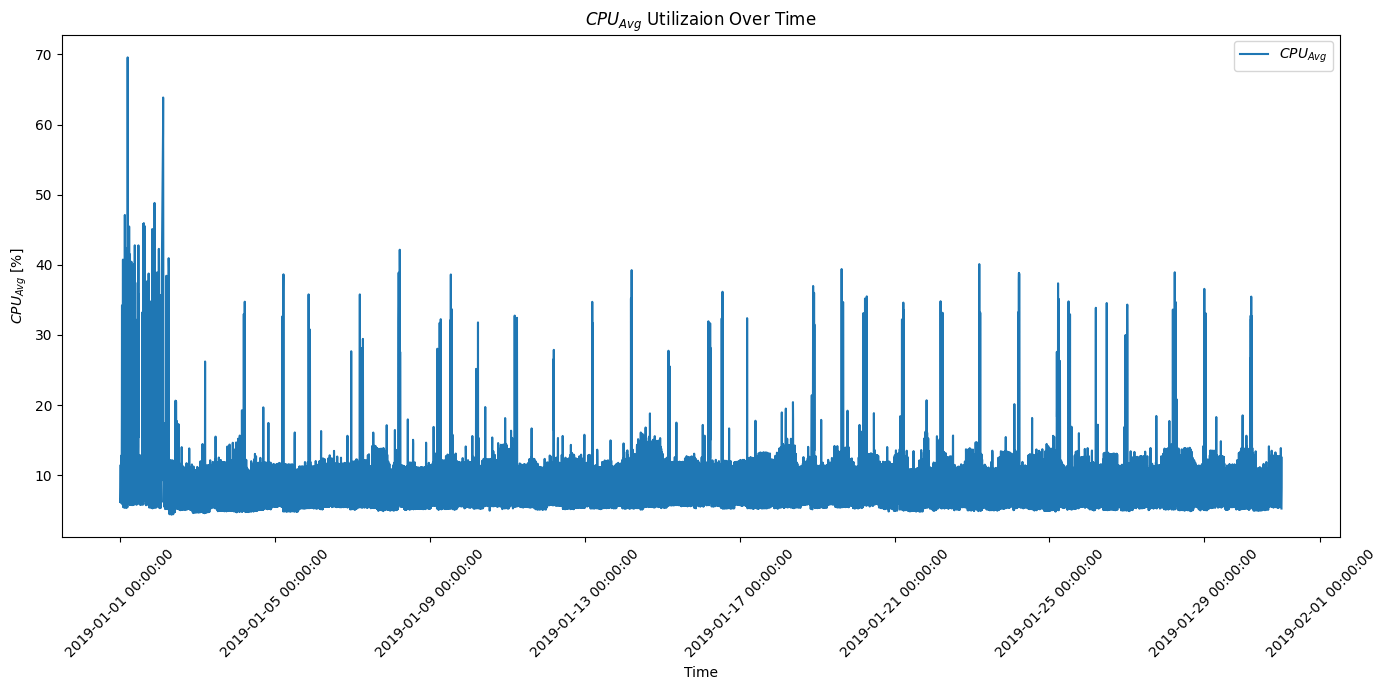

In [33]:
# Convert timestamp from epoch to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')
# Sort the dataframe by timestamp
data.sort_index(inplace=True)

# Plot avgcpu to check for trend or seasonality
plt.figure(figsize=(14, 7))
sns.lineplot(data=data, x='timestamp', y='avgcpu', label='$CPU_{Avg}$')
plt.title('$CPU_{Avg}$ Utilizaion Over Time')

#step_size = 287
#selected_ticks = df['timestamp'][::step_size]
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
#plt.xticks(selected_ticks, rotation=90)

plt.xlabel('Time')
plt.ylabel('$CPU_{Avg}$ [%]')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# **select predictive models**

In [34]:
# Predict intervals using in-sample residuals
# ==============================================================================
in_sample_residuals=True

class SortDataFrame(BaseEstimator, TransformerMixin):
    def __init__(self, column_name):
        self.column_name = column_name

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.sort_values(by=[self.column_name])


# Define custom transformers for the pipeline
class CheckSequence(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if not isinstance(X.index, pd.DatetimeIndex):
            raise TypeError('Index must be a DatetimeIndex.')

        time_diffs = X.index.to_series().diff().dt.total_seconds()
        if not time_diffs[1:].eq(300).all():
            raise ValueError('Data is not equally sequenced with 5-minute intervals.')
        return X


class DataSplitter(BaseEstimator, TransformerMixin):
    def __init__(self, steps):
        self.steps = steps

    def fit(self, X, y=None):
        return self

    def transform(self, data):
        data_train = data[:-self.steps]
        data_test = data[-self.steps:]
        return data_train, data_test
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class fill_nan_with_median(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Ensure X is a DataFrame and compute medians for later use
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        self.median_values_ = {
            'avgcpu': X['avgcpu'].median(),
            'mincpu': X['mincpu'].median(),
            'maxcpu': X['maxcpu'].median()
        }

        return self
    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        # Make a copy of the DataFrame to avoid modifying the original data
        X_filled = X.copy()

        # Fill NaN values with the computed medians
        for column in ['avgcpu', 'mincpu', 'maxcpu']:
            X_filled[column] = X_filled[column].fillna(self.median_values_[column])

        return X_filled

class fill_nan_with_linear(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        # Make a copy of the DataFrame to avoid modifying the original data
        X_interpolated = X.copy()

        # Fill NaN values using linear interpolation for specific columns
        X_interpolated[['avgcpu', 'mincpu', 'maxcpu']] = X_interpolated[['avgcpu', 'mincpu', 'maxcpu']].interpolate(method='linear')

        return X_interpolated

class fill_nan_with_nearest(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        # Make a copy of the DataFrame to avoid modifying the original data
        X_interpolated = X.copy()

        # Fill NaN values using nearest interpolation for specific columns
        X_interpolated[['avgcpu', 'mincpu', 'maxcpu']] = X_interpolated[['avgcpu', 'mincpu', 'maxcpu']].interpolate(method='nearest')

        return X_interpolated
class fill_nan_with_spline(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        # Make a copy of the DataFrame to avoid modifying the original data
        X_interpolated = X.copy()

        # Fill NaN values using spline interpolation for specific columns
        X_interpolated[['avgcpu', 'mincpu', 'maxcpu']] = X_interpolated[['avgcpu', 'mincpu', 'maxcpu']].interpolate(method='spline', order=1)

        return X_interpolated

class fill_nan_with_polynomial(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        # Make a copy of the DataFrame to avoid modifying the original data
        X_interpolated = X.copy()

        # Fill NaN values using polynomial interpolation for specific columns
        X_interpolated[['avgcpu', 'mincpu', 'maxcpu']] = X_interpolated[['avgcpu', 'mincpu', 'maxcpu']].interpolate(method='polynomial', order=1)

        return X_interpolated


class FillNaNWithDeepLearning(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None,
                 n_steps=100,
                 n_features=1,
                 n_layers=2,
                 d_model=256,
                 n_heads=4,
                 d_k=64,
                 d_v=64,
                 d_ffn=128,
                 dropout=0.1,
                 epochs=50):
        self.columns = columns if columns is not None else []
        self.n_steps = n_steps
        self.n_features = n_features
        self.n_layers = n_layers
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_k
        self.d_v = d_v
        self.d_ffn = d_ffn
        self.dropout = dropout
        self.epochs = epochs
        self.saits_models = {}

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        for column in self.columns:
            if column not in X.columns:
                raise ValueError(f"Column {column} does not exist in input DataFrame.")

            # Create and fit a model for each column
            self.saits_models[column] = SAITS(n_steps=self.n_steps, n_features=self.n_features, n_layers=self.n_layers,
                                              d_model=self.d_model, n_heads=self.n_heads, d_k=self.d_k,
                                              d_v=self.d_v, d_ffn=self.d_ffn, dropout=self.dropout,
                                              epochs=self.epochs,verbose=0)

            # Prepare the data for the model by reshaping
            dataset = X[[column]].to_numpy()
            if len(dataset) % self.n_steps != 0:
                pad_size = self.n_steps - (len(dataset) % self.n_steps)  # Calculate padding size
                dataset = np.pad(dataset, ((0, pad_size), (0, 0)), mode='constant', constant_values=np.nan)

            dataset = dataset.reshape(-1, self.n_steps, self.n_features)  # Reshape correctly to 3D
            self.saits_models[column].fit({"X": dataset})  # Fit the model
            self.saits_models[column].save("saits.pypots", overwrite=True)
        return self
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        X_imputed = X.copy()

        for column in self.columns:
            if column in self.saits_models:
                # Prepare the data for transformation by reshaping
                dataset = X[[column]].to_numpy()
                n_samples = dataset.shape[0]
                if n_samples < self.n_steps:
                    raise ValueError("Not enough samples in the dataset to reshape into 3D.")

                # Calculate padding size
                pad_size = self.n_steps - (n_samples % self.n_steps) if n_samples % self.n_steps != 0 else 0
                if pad_size > 0:
                    dataset = np.pad(dataset, ((0, pad_size), (0, 0)), mode='constant', constant_values=np.nan)

                # Re-shape
                dataset = dataset.reshape(-1, self.n_steps, self.n_features)

                # Impute missing values
                imputed_values = self.saits_models[column].impute({"X": dataset})
                imputed_values = imputed_values.flatten()

                # Remove any extra padded values to match the original DataFrame's length
                if len(imputed_values) > len(X_imputed):
                    imputed_values = imputed_values[:len(X_imputed)]

                # Ensure lengths match before assignment
                if len(imputed_values) != len(X_imputed):
                    raise ValueError(f"Imputed values length {len(imputed_values)} does not match the DataFrame length {len(X_imputed)}.")

                # Assign all rows for current column
                X_imputed.loc[:, column] = imputed_values

        return X_imputed


class FillMissingSequenceTimes(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Check if the index is a timestamp
        if not isinstance(X.index, pd.DatetimeIndex):
            raise KeyError("The DataFrame index is not a timestamp index.")

        start_time = X.index.min()
        end_time = X.index.max()
        # time_range = pd.date_range(start=start_time, end=end_time, freq='5T')  FutureWarning:
        time_range = pd.date_range(start=start_time, end=end_time, freq='5min')
        complete_df = pd.DataFrame(index=time_range)

        # Merge original DataFrame with the complete time range
        result_df = complete_df.join(X, how='left')
        return result_df

#  Define a custom transformer for adding vmid
class AddVmid(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X['vmid'] = X['vmid'].fillna(method='ffill')  ##warning
        X['vmid'] = X['vmid'].ffill() #
        return X

class ZScoreIQRDetector(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.threshold = 1.5

    def fit(self,columns, X, y=None):
        self.columns=columns
        self.X=X
        return self

    def transform(self, X):
        Q1 = X[self.columns].quantile(0.25)
        Q3 = X[self.columns].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - self.threshold * IQR
        upper_bound = Q3 + self.threshold * IQR

        # Calculate z-scores
        X['z_score'] = (X[self.columns] - X[self.columns].median()) / X[self.columns].std()

        # Identify outliers based on the IQR method
        X['is_outlier'] = ((X[self.columns] < lower_bound) | (X[self.columns] > upper_bound)).astype(int)

        # Replace global outliers with median of avgcpu
        X.loc[X['is_outlier'] == 1, self.columns] = X[self.columns].median()

        return X[[self.columns, 'z_score', 'is_outlier']]

class SavitzkyGolayFilter(BaseEstimator, TransformerMixin):
    def __init__(self, window_length=15, polyorder=2):
        self.window_length = window_length
        self.polyorder = polyorder

    def fit(self, X,column_name, y=None):
      self.column_name = column_name
      return self

    def transform(self, X):
        if self.column_name not in X.columns:
            raise ValueError(f"Column {self.column_name} does not exist in the DataFrame.")

        X_filtered = X.copy()
        X_filtered[self.column_name] = savgol_filter(X[self.column_name], window_length=self.window_length, polyorder=self.polyorder)

        return X_filtered

pre_processing_pipeline = Pipeline([
    ("check_Sequence", CheckSequence()),
    ("fill_missing_SequenceTimes", FillMissingSequenceTimes()),
])

fill_missing_pipeline = Pipeline([
    ("fill_nan_with_median",fill_nan_with_median()),
    ("fill_nan_with_linear",fill_nan_with_linear()),
    ("fill_nan_with_nearest",fill_nan_with_nearest()),
    ("fill_nan_with_spline",fill_nan_with_spline()),
    ("fill_nan_with_polynomial",fill_nan_with_polynomial()),
    ("FillNaNWithDeepLearning",FillNaNWithDeepLearning(columns=['avgcpu', 'mincpu', 'maxcpu'],n_features=1)),

    ("AddVmid" , AddVmid()),

])

z_score_pipeline = Pipeline([
    ("Clip",ZScoreIQRDetector())
])

denoising_pipeline = Pipeline([
     ("DE_noising",SavitzkyGolayFilter()),
])


used_pipeline_in_sample_residual = Pipeline([
    ("sort_by_timestamp",  FeatureUnion([('SortDataFrame',       SortDataFrame("timestamp"))])),
    ('sub_preprocessing',  FeatureUnion([('pre_processing',      pre_processing_pipeline)])),
    ('sub_fill_nan',       FeatureUnion([('FillMissingValues',   fill_missing_pipeline)])),
    ('sub_ClipOvershoots', FeatureUnion([('ClipOvershoots',      z_score_pipeline)])),
    ('sub_denoising',      FeatureUnion([('denoising_Filter',    denoising_pipeline)])),

])

used_pipeline_in_sample_residual

Pipeline(steps=[('sort_by_timestamp',
                 FeatureUnion(transformer_list=[('SortDataFrame',
                                                 SortDataFrame(column_name='timestamp'))])),
                ('sub_preprocessing',
                 FeatureUnion(transformer_list=[('pre_processing',
                                                 Pipeline(steps=[('check_Sequence',
                                                                  CheckSequence()),
                                                                 ('fill_missing_SequenceTimes',
                                                                  FillMissingSequenceTimes())]))])),
                ('sub_fill_nan',
                 FeatureUnion(transfor...
                                                                 ('FillNaNWithDeepLearning',
                                                                  FillNaNWithDeepLearning(columns=['avgcpu',
                                                                                                   'mincpu',
                                                                                                   'maxcpu'])),
                                                                 ('AddVmid',
                                                                  AddVmid())]))])),
                ('sub_ClipOvershoots',
                 FeatureUnion(transformer_list=[('ClipOvershoots',
                                                 Pipeline(steps=[('Clip',
                                                                  ZScoreIQRDetector())]))])),
                ('sub_denoising',
                 FeatureUnion(transformer_list=[('denoising_Filter',
                                                 Pipeline(steps=[('DE_noising',
                                                                  SavitzkyGolayFilter())]))]))])

In [35]:
sort_data_time = used_pipeline_in_sample_residual.get_params()['sort_by_timestamp__SortDataFrame']
sorted_df = sort_data_time.transform(data)

In [36]:
sorted_df

,timestamp,vmid,mincpu,maxcpu,avgcpu
889,2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775
890,2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830
891,2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942
892,2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744
893,2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860
...,...,...,...,...,...
5254,2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754
5255,2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148
5256,2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317
5257,2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279


In [37]:
check_processing_data = used_pipeline_in_sample_residual.get_params()['sub_preprocessing__pre_processing__check_Sequence']
sorted_df['timestamp'] = pd.to_datetime(sorted_df['timestamp'])  # Convert the column to datetime
sorted_df.set_index('timestamp', inplace=True)                   # Set it as the index
check_Sequence = check_processing_data.fit_transform(sorted_df)


ValueError: Data is not equally sequenced with 5-minute intervals.

# Detect and Filter missing records and missing gaps

In [38]:
fill_missing_times_processing = used_pipeline_in_sample_residual.get_params()['sub_preprocessing__pre_processing__fill_missing_SequenceTimes']
fill_missing_times_df         = fill_missing_times_processing.fit_transform(sorted_df)
fill_missing_times_df

,vmid,mincpu,maxcpu,avgcpu
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860
...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279


In [39]:
fill_missing_times_df.shape

(8639, 4)

In [40]:
fill_missing_times_df.isna().sum()

,0
vmid,8
mincpu,8
maxcpu,8
avgcpu,8


In [41]:
print(fill_missing_times_df[['avgcpu','mincpu', 'maxcpu']].isna().sum())

avgcpu    8
mincpu    8
maxcpu    8
dtype: int64


In [42]:
fill_missing_times_df['fixed_records'] = fill_missing_times_df['avgcpu'].isna().astype(int)
missing_records_with_NaN               = fill_missing_times_df[fill_missing_times_df['fixed_records'] == 1]
missing_records_with_NaN

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,NaN,NaN,NaN,NaN,1
2019-01-02 01:55:00,NaN,NaN,NaN,NaN,1
2019-01-02 02:00:00,NaN,NaN,NaN,NaN,1
2019-01-02 02:05:00,NaN,NaN,NaN,NaN,1
2019-01-02 02:10:00,NaN,NaN,NaN,NaN,1
2019-01-02 02:15:00,NaN,NaN,NaN,NaN,1
2019-01-02 02:20:00,NaN,NaN,NaN,NaN,1
2019-01-02 02:25:00,NaN,NaN,NaN,NaN,1


# Apply imputations methods over missing data

#### fill_nan_with_median

In [43]:
filler_median = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__fill_nan_with_median']
filler_median.fit(fill_missing_times_df)
df_filled1 = filler_median.transform(fill_missing_times_df)
df_filled1

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279,0


In [44]:
df_filled1.shape

(8639, 5)

In [45]:
df_filled1.isna().sum()

,0
vmid,8
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [46]:
imputed_NaN_values_records = df_filled1[df_filled1['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,NaN,4.463165,22.347455,7.867511,1
2019-01-02 01:55:00,NaN,4.463165,22.347455,7.867511,1
2019-01-02 02:00:00,NaN,4.463165,22.347455,7.867511,1
2019-01-02 02:05:00,NaN,4.463165,22.347455,7.867511,1
2019-01-02 02:10:00,NaN,4.463165,22.347455,7.867511,1
2019-01-02 02:15:00,NaN,4.463165,22.347455,7.867511,1
2019-01-02 02:20:00,NaN,4.463165,22.347455,7.867511,1
2019-01-02 02:25:00,NaN,4.463165,22.347455,7.867511,1


In [47]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final1=addVmiddata.transform(df_filled1)


In [48]:
df_final1

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279,0


In [49]:
df_final1.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [50]:
imputed_NaN_values_records = df_final1[df_final1['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.463165,22.347455,7.867511,1
2019-01-02 01:55:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.463165,22.347455,7.867511,1
2019-01-02 02:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.463165,22.347455,7.867511,1
2019-01-02 02:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.463165,22.347455,7.867511,1
2019-01-02 02:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.463165,22.347455,7.867511,1
2019-01-02 02:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.463165,22.347455,7.867511,1
2019-01-02 02:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.463165,22.347455,7.867511,1
2019-01-02 02:25:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.463165,22.347455,7.867511,1


#### Interpolation(Linear)

In [51]:
filler_linear = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__fill_nan_with_linear']
filler_linear.fit(fill_missing_times_df)
df_filled2 = filler_linear.transform(fill_missing_times_df)
df_filled2

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279,0


In [52]:
df_filled2.shape

(8639, 5)

In [53]:
df_filled2.isna().sum()

,0
vmid,8
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [54]:
imputed_NaN_values_records = df_filled2[df_filled2['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,NaN,10.200351,95.099198,41.354641,1
2019-01-02 01:55:00,NaN,14.496642,91.968679,43.527399,1
2019-01-02 02:00:00,NaN,18.792933,88.838159,45.700157,1
2019-01-02 02:05:00,NaN,23.089223,85.707640,47.872915,1
2019-01-02 02:10:00,NaN,27.385514,82.577120,50.045673,1
2019-01-02 02:15:00,NaN,31.681805,79.446600,52.218431,1
2019-01-02 02:20:00,NaN,35.978095,76.316081,54.391189,1
2019-01-02 02:25:00,NaN,40.274386,73.185561,56.563947,1


In [55]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final2=addVmiddata.transform(df_filled2)


In [56]:
df_final2

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279,0


In [57]:
df_final2.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [58]:
imputed_NaN_values_records = df_final2[df_final2['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,10.200351,95.099198,41.354641,1
2019-01-02 01:55:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,14.496642,91.968679,43.527399,1
2019-01-02 02:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,18.792933,88.838159,45.700157,1
2019-01-02 02:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,23.089223,85.707640,47.872915,1
2019-01-02 02:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,27.385514,82.577120,50.045673,1
2019-01-02 02:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,31.681805,79.446600,52.218431,1
2019-01-02 02:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,35.978095,76.316081,54.391189,1
2019-01-02 02:25:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,40.274386,73.185561,56.563947,1


#### Interpolation(nearest)

In [59]:
filler_nearest = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__fill_nan_with_nearest']
filler_nearest.fit(fill_missing_times_df)
df_filled3 = filler_nearest.transform(fill_missing_times_df)
df_filled3

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279,0


In [60]:
df_filled3.shape

(8639, 5)

In [61]:
df_filled3.isna().sum()

,0
vmid,8
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [62]:
imputed_NaN_values_records = df_filled3[df_filled3['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,NaN,5.904061,98.229718,39.181883,1
2019-01-02 01:55:00,NaN,5.904061,98.229718,39.181883,1
2019-01-02 02:00:00,NaN,5.904061,98.229718,39.181883,1
2019-01-02 02:05:00,NaN,5.904061,98.229718,39.181883,1
2019-01-02 02:10:00,NaN,44.570676,70.055042,58.736705,1
2019-01-02 02:15:00,NaN,44.570676,70.055042,58.736705,1
2019-01-02 02:20:00,NaN,44.570676,70.055042,58.736705,1
2019-01-02 02:25:00,NaN,44.570676,70.055042,58.736705,1


In [63]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final3=addVmiddata.transform(df_filled3)


In [64]:
df_final3

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279,0


In [65]:
df_final3.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [66]:
imputed_NaN_values_records = df_final3[df_final3['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,5.904061,98.229718,39.181883,1
2019-01-02 01:55:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,5.904061,98.229718,39.181883,1
2019-01-02 02:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,5.904061,98.229718,39.181883,1
2019-01-02 02:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,5.904061,98.229718,39.181883,1
2019-01-02 02:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,44.570676,70.055042,58.736705,1
2019-01-02 02:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,44.570676,70.055042,58.736705,1
2019-01-02 02:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,44.570676,70.055042,58.736705,1
2019-01-02 02:25:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,44.570676,70.055042,58.736705,1


#### Interpolation(spline)

In [67]:
filler_spline = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__fill_nan_with_spline']
filler_spline.fit(fill_missing_times_df)
df_filled4 = filler_spline.transform(fill_missing_times_df)
df_filled4

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279,0


In [68]:
df_filled4.shape

(8639, 5)

In [69]:
df_filled4.isna().sum()

,0
vmid,8
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [70]:
imputed_NaN_values_records = df_filled4[df_filled4['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,NaN,4.577042,94.890120,41.004219,1
2019-01-02 01:55:00,NaN,4.577033,91.800360,43.394673,1
2019-01-02 02:00:00,NaN,4.577024,88.710600,45.785127,1
2019-01-02 02:05:00,NaN,4.577015,85.620840,48.175580,1
2019-01-02 02:10:00,NaN,4.577005,82.531080,50.566034,1
2019-01-02 02:15:00,NaN,4.576996,79.441320,52.956487,1
2019-01-02 02:20:00,NaN,4.576987,76.351559,55.346941,1
2019-01-02 02:25:00,NaN,4.576978,73.261799,57.737394,1


In [71]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final4=addVmiddata.transform(df_filled4)


In [72]:
df_final4

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279,0


In [73]:
df_final4.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [74]:
imputed_NaN_values_records = df_final4[df_final4['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.577042,94.890120,41.004219,1
2019-01-02 01:55:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.577033,91.800360,43.394673,1
2019-01-02 02:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.577024,88.710600,45.785127,1
2019-01-02 02:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.577015,85.620840,48.175580,1
2019-01-02 02:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.577005,82.531080,50.566034,1
2019-01-02 02:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.576996,79.441320,52.956487,1
2019-01-02 02:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.576987,76.351559,55.346941,1
2019-01-02 02:25:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.576978,73.261799,57.737394,1


#### Interpolation(polynomial)

In [75]:
filler_polynomial = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__fill_nan_with_polynomial']
filler_polynomial.fit(fill_missing_times_df)
df_filled5 = filler_polynomial.transform(fill_missing_times_df)
df_filled5

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279,0


In [76]:
df_filled5.shape

(8639, 5)

In [77]:
df_filled5.isna().sum()

,0
vmid,8
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [78]:
imputed_NaN_values_records = df_filled5[df_filled5['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,NaN,10.200351,95.099198,41.354641,1
2019-01-02 01:55:00,NaN,14.496642,91.968679,43.527399,1
2019-01-02 02:00:00,NaN,18.792933,88.838159,45.700157,1
2019-01-02 02:05:00,NaN,23.089223,85.707640,47.872915,1
2019-01-02 02:10:00,NaN,27.385514,82.577120,50.045673,1
2019-01-02 02:15:00,NaN,31.681805,79.446600,52.218431,1
2019-01-02 02:20:00,NaN,35.978095,76.316081,54.391189,1
2019-01-02 02:25:00,NaN,40.274386,73.185561,56.563947,1


In [79]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final5=addVmiddata.transform(df_filled5)


In [80]:
df_final4

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770830,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906176,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186247,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850383,12.609279,0


In [81]:
df_final5.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [82]:
imputed_NaN_values_records = df_final5[df_final5['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,10.200351,95.099198,41.354641,1
2019-01-02 01:55:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,14.496642,91.968679,43.527399,1
2019-01-02 02:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,18.792933,88.838159,45.700157,1
2019-01-02 02:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,23.089223,85.707640,47.872915,1
2019-01-02 02:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,27.385514,82.577120,50.045673,1
2019-01-02 02:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,31.681805,79.446600,52.218431,1
2019-01-02 02:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,35.978095,76.316081,54.391189,1
2019-01-02 02:25:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,40.274386,73.185561,56.563947,1


#### Fill NaN With DeepLearning

In [83]:
filler_DeepLearning = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__FillNaNWithDeepLearning']
filler_DeepLearning.fit(fill_missing_times_df)


2025-03-17 18:58:12 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-03-17 19:01:59 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-03-17 19:03:51 [WARNING]: ‼️ File ./saits.pypots exists. Argument `overwrite` is True. Overwriting now...
2025-03-17 19:03:51 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-03-17 19:07:27 [WARNING]: ‼️ File ./saits.pypots exists. Argument `overwrite` is True. Overwriting now...


FillNaNWithDeepLearning(columns=['avgcpu', 'mincpu', 'maxcpu'])

In [84]:
filler_DeepLearning

FillNaNWithDeepLearning(columns=['avgcpu', 'mincpu', 'maxcpu'])

In [85]:
df_filled6 = filler_DeepLearning.transform(fill_missing_times_df)
df_filled6

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770831,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906178,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186245,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850384,12.609279,0


In [86]:
df_filled6.shape

(8639, 5)

In [87]:
df_filled6.isna().sum()

,0
vmid,8
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [88]:
imputed_NaN_values_records = df_filled6[df_filled6['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,NaN,4.149027,19.171659,8.318650,1
2019-01-02 01:55:00,NaN,4.149714,19.174471,8.318782,1
2019-01-02 02:00:00,NaN,4.151710,19.172543,8.318945,1
2019-01-02 02:05:00,NaN,4.153317,19.180391,8.319044,1
2019-01-02 02:10:00,NaN,4.153585,19.177229,8.319022,1
2019-01-02 02:15:00,NaN,4.151805,19.179581,8.318901,1
2019-01-02 02:20:00,NaN,4.149395,19.176693,8.318793,1
2019-01-02 02:25:00,NaN,4.147934,19.173851,8.318789,1


In [89]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final6=addVmiddata.transform(df_filled6)


In [90]:
df_final6

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.646734,11.794065,6.175775,0
2019-01-01 00:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.800877,11.247899,6.770831,0
2019-01-01 00:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.843798,33.906178,9.118942,0
2019-01-01 00:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.608447,36.416206,11.463744,0
2019-01-01 00:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.795262,11.782295,6.160860,0
...,...,...,...,...,...
2019-01-30 23:30:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.677881,8.106423,5.431754,0
2019-01-30 23:35:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.272844,20.599508,6.698148,0
2019-01-30 23:40:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.472174,34.186245,8.255317,0
2019-01-30 23:45:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.833878,46.850384,12.609279,0


In [91]:
df_final6.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [92]:
imputed_NaN_values_records = df_final6[df_final6['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-02 01:50:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.149027,19.171659,8.318650,1
2019-01-02 01:55:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.149714,19.174471,8.318782,1
2019-01-02 02:00:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.151710,19.172543,8.318945,1
2019-01-02 02:05:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.153317,19.180391,8.319044,1
2019-01-02 02:10:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.153585,19.177229,8.319022,1
2019-01-02 02:15:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.151805,19.179581,8.318901,1
2019-01-02 02:20:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.149395,19.176693,8.318793,1
2019-01-02 02:25:00,/KlNtIK2BCkiGhURgesiA/MQNyTpAgt7daSRsu2kJldWyC...,4.147934,19.173851,8.318789,1


# Visualize and compare the imputation results

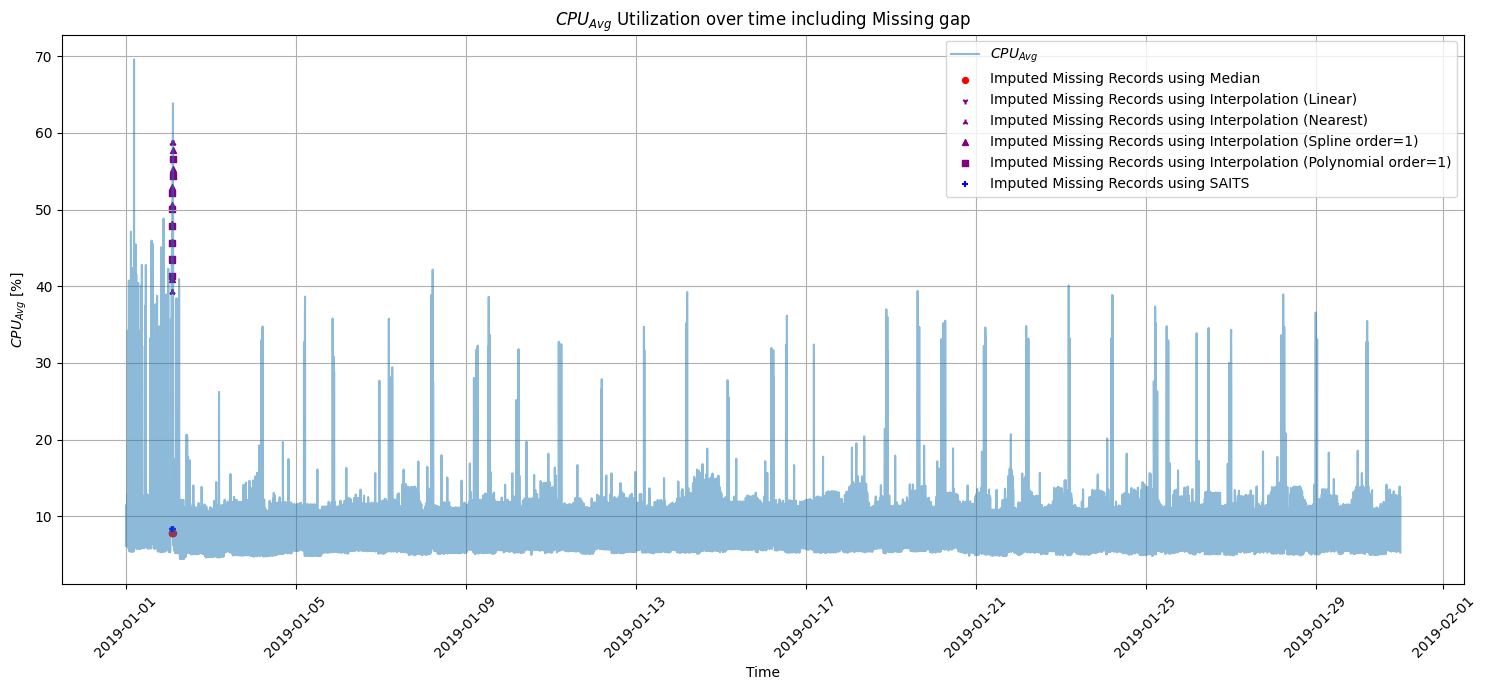

In [93]:
import matplotlib.pyplot as plt

# Filter the records that have been added
imputed_NaN_values_records1 = df_final1[df_final1['fixed_records'] == 1]
imputed_NaN_values_records2 = df_final2[df_final2['fixed_records'] == 1]
imputed_NaN_values_records3 = df_final3[df_final3['fixed_records'] == 1]
imputed_NaN_values_records4 = df_final4[df_final4['fixed_records'] == 1]
imputed_NaN_values_records5 = df_final5[df_final5['fixed_records'] == 1]
imputed_NaN_values_records6 = df_final6[df_final6['fixed_records'] == 1]

# Plot the original data with missing records highlighted and annotated
plt.figure(figsize=(15, 7))
sns.lineplot(data=data, x='timestamp', y='avgcpu', label='$CPU_{Avg}$', alpha=0.5)
plt.scatter(imputed_NaN_values_records1.index, imputed_NaN_values_records1['avgcpu'], color='r', label='Imputed Missing Records using Median', marker='o', s=18)
plt.scatter(imputed_NaN_values_records2.index, imputed_NaN_values_records2['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Linear)', marker='1', s=18)
plt.scatter(imputed_NaN_values_records3.index, imputed_NaN_values_records3['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Nearest)', marker='2', s=18)
plt.scatter(imputed_NaN_values_records4.index, imputed_NaN_values_records4['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Spline order=1)', marker='^', s=18)
plt.scatter(imputed_NaN_values_records5.index, imputed_NaN_values_records5['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Polynomial order=1)', marker='s', s=18)
plt.scatter(imputed_NaN_values_records6.index, imputed_NaN_values_records6['avgcpu'], color='b', label='Imputed Missing Records using SAITS', marker='+', s=18)

plt.title('$CPU_{Avg}$ Utilization over time including Missing gap')
plt.xlabel('Time')
plt.ylabel('$CPU_{Avg}$ [%]')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

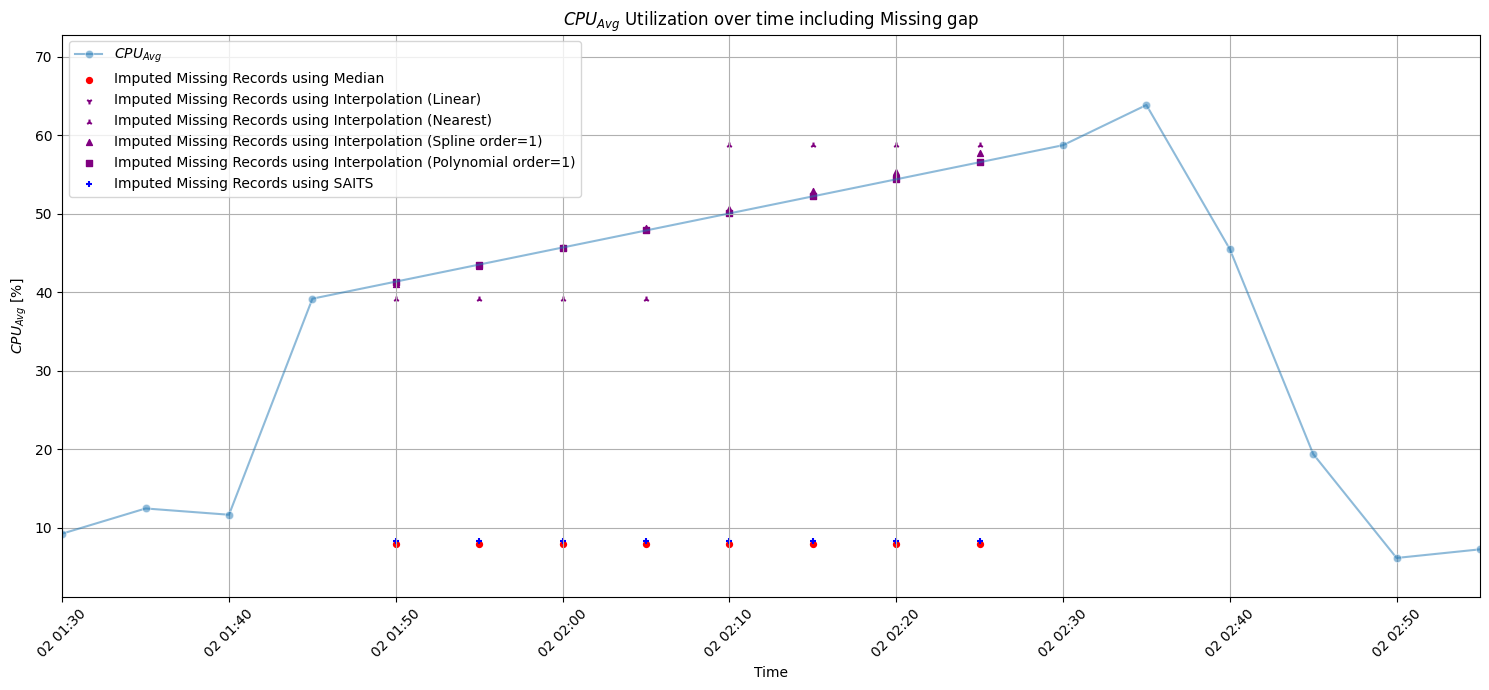

In [121]:
# Filter the records that have been added
imputed_NaN_values_records1 = df_final1[df_final1['fixed_records'] == 1]
imputed_NaN_values_records2 = df_final2[df_final2['fixed_records'] == 1]
imputed_NaN_values_records3 = df_final3[df_final3['fixed_records'] == 1]
imputed_NaN_values_records4 = df_final4[df_final4['fixed_records'] == 1]
imputed_NaN_values_records5 = df_final5[df_final5['fixed_records'] == 1]
imputed_NaN_values_records6 = df_final6[df_final6['fixed_records'] == 1]

# Define the x-axis limits
start_time = pd.to_datetime("2019-01-02 01:30:00")
end_time   = pd.to_datetime("2019-01-02 02:55:00")

# Plot the original data with missing records highlighted and annotated, with x-axis limits
plt.figure(figsize=(15, 7))
sns.lineplot(data=data, x='timestamp', y='avgcpu', label='$CPU_{Avg}$', marker='o', alpha=0.5)
plt.scatter(imputed_NaN_values_records1.index, imputed_NaN_values_records1['avgcpu'], color='r', label='Imputed Missing Records using Median', marker='o', s=18)
plt.scatter(imputed_NaN_values_records2.index, imputed_NaN_values_records2['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Linear)', marker='1', s=18)
plt.scatter(imputed_NaN_values_records3.index, imputed_NaN_values_records3['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Nearest)', marker='2', s=18)
plt.scatter(imputed_NaN_values_records4.index, imputed_NaN_values_records4['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Spline order=1)', marker='^', s=18)
plt.scatter(imputed_NaN_values_records5.index, imputed_NaN_values_records5['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Polynomial order=1)', marker='s', s=18)
plt.scatter(imputed_NaN_values_records6.index, imputed_NaN_values_records6['avgcpu'], color='b', label='Imputed Missing Records using SAITS', marker='+', s=18)

plt.title('$CPU_{Avg}$ Utilization over time including Missing gap')
plt.xlabel('Time')
plt.ylabel('$CPU_{Avg}$ [%]')
plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time) # Set x-axis limits
plt.tight_layout()
plt.grid()
plt.show()

##Logging | Notebook END Time

In [96]:
NOTEBOOK_END_TIME_UC0   = time.time()  #now.strftime("%Y-%m-%d %H:%M:%S") #time.time_ns()    #time.time()
#NOTEBOOK_EXECUTION_TIME_UC8 = (NOTEBOOK_END_TIME_UC11 - NOTEBOOK_START_TIME_UC11 ) / 1e9d

time_delta_total_seconds = (NOTEBOOK_END_TIME_UC0 - NOTEBOOK_START_TIME_UC0)
NOTEBOOK_EXECUTION_TIME_UC0 = time_delta_total_seconds/60

print(f"================[INFO]_${zeit}=======================")
print(f"| Notebook was successfully executed in {NOTEBOOK_EXECUTION_TIME_UC0} minutes | \n ------------------------------------------------------------------ ")

================[INFO]_$2025-03-17 18:57:41=======================
| Notebook was successfully executed in 9.818568571408589 minutes | 
 ------------------------------------------------------------------ 
